# numpy 라이브러리 이해

- 통계, 분석, AI 분야의 라이브러리 내부에 다양한 수치연산이 필요함
  + 수치연산을 얼마나 효율적으로 처리하는가에 따라 성능에 많은 영향을 줌
  + numpy 는 ndarray 라는 자료를 바탕으로 강력한 연산 기능을 제공함
- numpy 와 다른 python 패키지와의 관계
  ![nn](./images/numpy-01.png)

# ndarray 성능 확인

In [1]:
import numpy as np

In [2]:
a = [1, 2, 3]
b = [4, 5, 6]
c = []

for a, b in zip(a, b):
    c.append(a+b)
    
print(c)

[5, 7, 9]


In [3]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
c = a + b

print(c)

[5 7 9]


In [4]:
a = [[1,2,3,4] for _ in range(1000000)]
b = np.array(a)

def exchange_list(a):
    c = []
    for x in a:
        x[2], x[3], x[0], x[1] = x
        c.append(x)
    return c

def exchange_ndarray(a):
    return a[ : , [2, 3, 0, 1]]

In [5]:
print(a[:2], b[:2], sep='\n')

[[1, 2, 3, 4], [1, 2, 3, 4]]
[[1 2 3 4]
 [1 2 3 4]]


In [6]:
c = exchange_list(a)

In [7]:
d = exchange_ndarray(b)

In [8]:
print(c[:2], d[:2], sep='\n')

[[3, 4, 1, 2], [3, 4, 1, 2]]
[[3 4 1 2]
 [3 4 1 2]]


In [9]:
%timeit exchange_list(a)

127 ms ± 470 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [10]:
%timeit exchange_ndarray(b)

3.83 ms ± 319 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


# ndarray 가 list 보다 빠른 이유

- numpy 의 ndarray와 built-in list 의 데이터 접근 방법 차이

![nn](./images/numpy-02.png)

https://github.com/numpy/numpy/blob/maintenance/1.7.x/numpy/core/include/numpy/ndarraytypes.h#L646
https://hg.python.org/cpython/file/3.6/Include/listobject.h#l23
https://hg.python.org/cpython/file/3.6/Include/longintrepr.h/#l85

# ndarray 의 속성

In [11]:
import numpy as np

In [12]:
def printinfo(a):
    data = ['a.ndim', 'a.shape', 'a.size', 'a.dtype', 'a.itemsize', 'a.strides', 'a.nbytes']
    for x in data:
        print('%-11s' % x, eval(x))

a = np.array([[0,1,2], [3,4,5]], dtype=np.int32)
printinfo(a)

a.ndim      2
a.shape     (2, 3)
a.size      6
a.dtype     int32
a.itemsize  4
a.strides   (12, 4)
a.nbytes    24


# ndarray 생성 - np.array()

In [13]:
import numpy as np

In [14]:
def printary(*a):
    for x in a:
        print(f'{type(x)}\n{x.dtype}\n{x}', end='\n\n')
    print("-" * 30)

In [15]:
a = np.array([1,2,3])
b = np.array([[1,2,3], [4,5,6]])
c = np.array([[1,2,3], [4,5]])
printary(a, b, c)

<class 'numpy.ndarray'>
int64
[1 2 3]

<class 'numpy.ndarray'>
int64
[[1 2 3]
 [4 5 6]]

<class 'numpy.ndarray'>
object
[list([1, 2, 3]) list([4, 5])]

------------------------------


/var/folders/3k/bgnrnfc15w792712mgb6g0_c0000gn/T/ipykernel_6901/3341886738.py:3: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  c = np.array([[1,2,3], [4,5]])


# structured array - np.array()

- ndarray 가 모든 element를 동일 type 으로 하지 않고, column 별로 다른 type 을 사용하는 구조
- 하기 예시는 Big Endian, Little Endian 을 참조할 것
- 권장하지 않음

In [16]:
sdtype = [('name', '<U10'), ('height', '<i4'), ('weight', np.float32)]
value =  [('Tome', 178, 98.5), ('Jim', 183, 79.5), ('Adam', 175, 82.8)]

a = np.array(value, dtype=sdtype)

printary(a)

<class 'numpy.ndarray'>
[('name', '<U10'), ('height', '<i4'), ('weight', '<f4')]
[('Tome', 178, 98.5) ('Jim', 183, 79.5) ('Adam', 175, 82.8)]

------------------------------


In [17]:
printary(a['name'], a['height'], a['weight'])
printary(a[0], a[1], a[2])
print(a.shape, a.strides, a[0])

<class 'numpy.ndarray'>
<U10
['Tome' 'Jim' 'Adam']

<class 'numpy.ndarray'>
int32
[178 183 175]

<class 'numpy.ndarray'>
float32
[98.5 79.5 82.8]

------------------------------
<class 'numpy.void'>
[('name', '<U10'), ('height', '<i4'), ('weight', '<f4')]
('Tome', 178, 98.5)

<class 'numpy.void'>
[('name', '<U10'), ('height', '<i4'), ('weight', '<f4')]
('Jim', 183, 79.5)

<class 'numpy.void'>
[('name', '<U10'), ('height', '<i4'), ('weight', '<f4')]
('Adam', 175, 82.8)

------------------------------
(3,) (48,) ('Tome', 178, 98.5)


# ndarray 생성 - np.arange()

In [18]:
a = np.arange(5)
b = np.arange(1, 10, 2)
c = np.arange(1, 2, 0.1)

printary(a, b, c)

<class 'numpy.ndarray'>
int64
[0 1 2 3 4]

<class 'numpy.ndarray'>
int64
[1 3 5 7 9]

<class 'numpy.ndarray'>
float64
[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9]

------------------------------


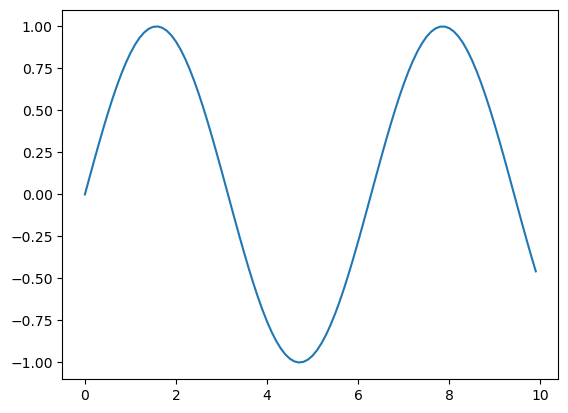

In [19]:
# 그래프를 그릴 때 축설정으로 사용 예
import matplotlib.pyplot as plt

x = np.arange(0, 10, 0.1)
y = np.sin(x)

plt.plot(x, y)

plt.show()

# ndarray 생성 - np.linspace()

- linear space 라고 읽는다!
- np.linspace(start: array_like, stop, num=50, endpoint=True, retstep=False, dtype=None)

In [20]:
x = np.array(1) # 1개만 있는 값도 (scalar) array-like 임
print(x, type(x))

1 <class 'numpy.ndarray'>


In [21]:
a = np.linspace(1, 5, 9) # 1부터 5까지 9개의 원소를 가는 array, 간격은 알아서 결정
b = np.linspace(1, 5, 10, endpoint=False)
c, step = np.linspace(1, 5, 9, retstep=True)  # c가 array, d 가 step

print(a, b, c, step, sep='\n')

[1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
[1.  1.4 1.8 2.2 2.6 3.  3.4 3.8 4.2 4.6]
[1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
0.5


In [22]:
x = np.linspace([1,2,3], [2,4,6], num=5)
print(x)

[[1.   2.   3.  ]
 [1.25 2.5  3.75]
 [1.5  3.   4.5 ]
 [1.75 3.5  5.25]
 [2.   4.   6.  ]]


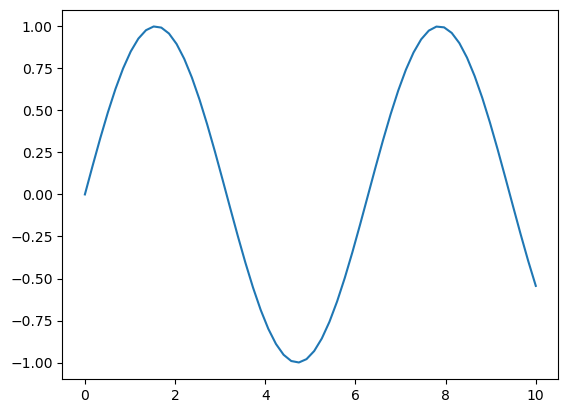

In [23]:
x = np.linspace(0, 10, 60)
y = np.sin(x)

plt.plot(x, y)
plt.show()

# random 사용

- `np.random.rand(d0, d1, ... dn)`
    + 0 ~ 1 사이의 균등 분포로 실수 난수 배열 생성
    + d0, d1, ... dn : 배열의 shape 의 의미하는 정수
- `np.random.randint(e, size=n)`, `np.random.randint(s, e, size=n)`
    + 0 ~ $e-1$, s ~ $e-1$ 범위의 값을 갖는 균등 분포의 정수 난수 생성
    + size: 정수(1차원), tuple(1차원 이상)로 shape 을 지정
- `np.random.randn(d0, d1, ... dn)`
    + 평균 0, 표준편차 1을 갖는 가우시안 정규분포로 난수 배열 생성 (음수 포함)
- `np.random.normal(평균, 표준편차, size)`
    + 생략하면 평균 = 0, 표준편차 = 1, size = 1
- `np.random.permutation(e)` : 0 ~ e-1 값을 갖는 정수의 무작위 순서 1차원 배열 생성
- `np.random.permutation(c)` : c 요소들에 대해 무작위 순서로 변경된 1차원 배열 생성
    + e: 정수, c : array_like 객체

In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
np.set_printoptions(threshold=999, 
                    suppress=True, 
                    precision=4, 
                    edgeitems=3)

In [26]:
def printary(*a):
    for x in a:
        print(f"shape: {x.shape}")
        print(f"array: %s{x}" % ('' if x.ndim == 1 else '\n'))
        print("mean : %.3f, std: %.3f" % (x.mean(), x.std()))
        print("-" * 30)

In [27]:
def showHist(x):
    plt.hist(x)
    plt.show()

In [28]:
a = np.random.rand(5)
b = np.random.rand(2, 2, 3)

printary(a, b)

shape: (5,)
array: [0.1295 0.8047 0.7435 0.0324 0.088 ]
mean : 0.360, std: 0.340
------------------------------
shape: (2, 2, 3)
array: 
[[[0.7214 0.9469 0.4431]
  [0.3935 0.2795 0.7498]]

 [[0.0316 0.4215 0.7049]
  [0.428  0.9526 0.4447]]]
mean : 0.543, std: 0.263
------------------------------


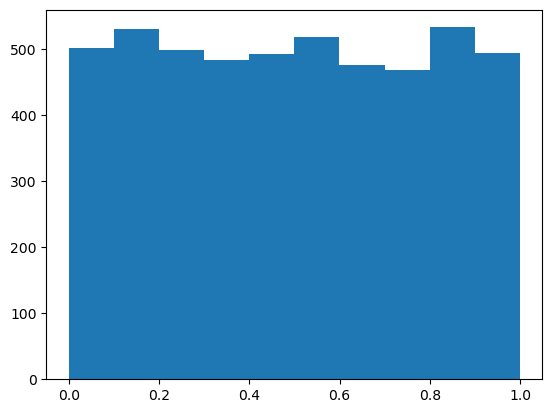

In [29]:
showHist(np.random.rand(5000))

In [30]:
a = np.random.randint(10, size=(5,))
b = np.random.randint(50, 100, (2, 4))

printary(a, b)

shape: (5,)
array: [8 3 6 2 0]
mean : 3.800, std: 2.857
------------------------------
shape: (2, 4)
array: 
[[53 71 76 67]
 [66 67 90 70]]
mean : 70.000, std: 9.747
------------------------------


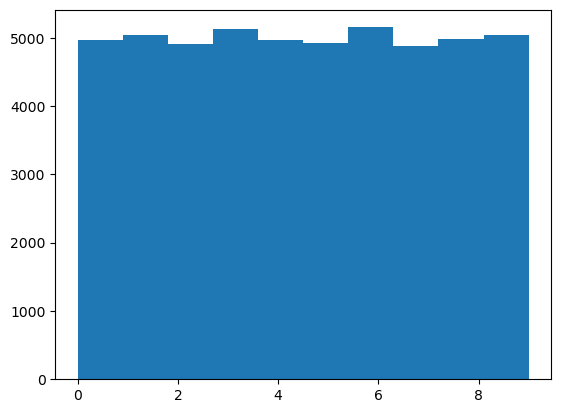

In [31]:
showHist(np.random.randint(10, size=50000))

In [32]:
a = np.random.randn(5)
b = np.random.randn(200, 50)

printary(a, b)

shape: (5,)
array: [-0.4783  1.9414  0.0756  1.5308  0.9913]
mean : 0.812, std: 0.898
------------------------------
shape: (200, 50)
array: 
[[-0.3669  0.4546 -0.2764 ... -2.3344  0.4581 -0.8436]
 [-0.4093 -0.1165  0.3211 ... -0.5295 -1.0129 -0.4052]
 [-0.8134  0.0089 -0.2725 ...  0.9354  1.0636  0.6796]
 ...
 [-0.4688 -0.6838  0.2799 ...  0.8556 -0.5639 -0.0768]
 [ 0.2053 -1.4781  0.4518 ... -0.0104 -0.4817 -0.7886]
 [ 2.306   0.7262 -0.9688 ...  0.0149  2.0125  0.1899]]
mean : -0.002, std: 1.005
------------------------------


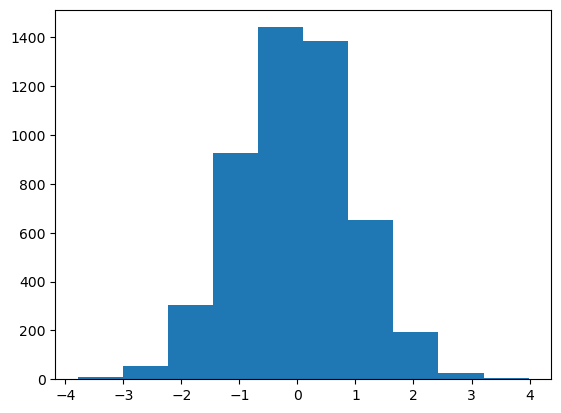

In [33]:
showHist(np.random.randn(5000))

In [34]:
a = np.random.normal(2, 3, (100, 20))

printary(a)

shape: (100, 20)
array: 
[[ 6.0214  0.241   0.7396 ...  2.6406 -0.7869  2.1086]
 [ 6.9858 -1.5169  7.0402 ...  3.7753 -2.6417 -0.2379]
 [ 0.0532  0.0372  1.7891 ...  1.3754  2.8606 -0.6759]
 ...
 [ 2.9088 -1.372   1.9724 ...  8.547   3.7078  1.6483]
 [-4.0772 -4.4617 -3.0929 ...  6.0277  7.2831 -1.1673]
 [-0.346   4.252   5.102  ... -3.4779  6.4133  1.5688]]
mean : 2.013, std: 3.004
------------------------------


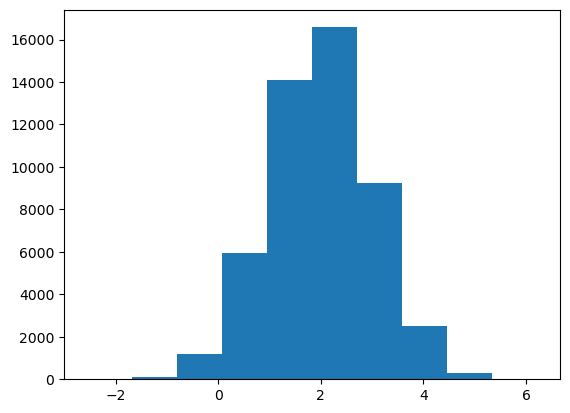

In [35]:
showHist(np.random.normal(2, 1, (50000,)))

In [36]:
a = np.random.permutation(10)
data = np.array([1,3,4,5,3,1,3])
b = np.random.permutation(data)
mylist = [[1,2,3], [4,5,6], [7,8,9], [3,2,1]]
c = np.random.permutation(mylist)

printary(a, b, c)

shape: (10,)
array: [8 5 1 0 2 9 7 4 3 6]
mean : 4.500, std: 2.872
------------------------------
shape: (7,)
array: [1 5 3 1 4 3 3]
mean : 2.857, std: 1.355
------------------------------
shape: (4, 3)
array: 
[[4 5 6]
 [7 8 9]
 [3 2 1]
 [1 2 3]]
mean : 4.250, std: 2.618
------------------------------


# 특정값으로 채원진 ndarrauy 생성